In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("../data/Reviews.csv")

In [5]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [6]:
df.shape

(568454, 10)

In [7]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [9]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [10]:
df = df.dropna(subset=['Summary'])

In [11]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                    0
Text                       0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df[['Score', 'Time', 'Summary', 'Text']]

In [14]:
df.head()

,Score,Time,Summary,Text
0,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [15]:
df['Time'] = pd.to_datetime(df['Time'], unit='s')

In [16]:
df.head()

,Score,Time,Summary,Text
0,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,2011-06-13,Cough Medicine,If you are looking for the secret ingredient i...
4,5,2012-10-21,Great taffy,Great taffy at a great price. There was a wid...


In [17]:
df.to_csv("../data/clean_reviews.csv", index=False)

In [18]:
#Exploratory Data Analysis (EDA)

In [19]:
len(df)

568427

In [20]:
df['Score'].mean()

np.float64(4.183298822891945)

In [21]:
df['Score'].value_counts()

Score
5    363122
4     80655
1     52268
3     42638
2     29744
Name: count, dtype: int64

In [22]:
df['Score'].value_counts().sort_index()

Score
1     52268
2     29744
3     42638
4     80655
5    363122
Name: count, dtype: int64

In [23]:
import matplotlib.pyplot as plt

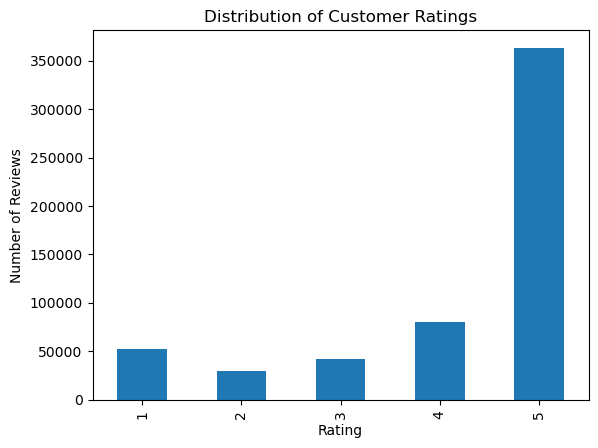

In [24]:
df['Score'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

In [25]:
(df['Score'].value_counts(normalize=True) * 100).sort_index()

Score
1     9.195200
2     5.232686
3     7.501051
4    14.189157
5    63.881906
Name: proportion, dtype: float64

In [26]:
#Sentiment Analysis

In [27]:
def sentiment(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['Score'].apply(sentiment)

In [28]:
df.head()

,Score,Time,Summary,Text,Sentiment
0,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive
1,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...,Positive
3,2,2011-06-13,Cough Medicine,If you are looking for the secret ingredient i...,Negative
4,5,2012-10-21,Great taffy,Great taffy at a great price. There was a wid...,Positive


In [29]:
df['Sentiment'].value_counts()

Sentiment
Positive    443777
Negative     82012
Neutral      42638
Name: count, dtype: int64

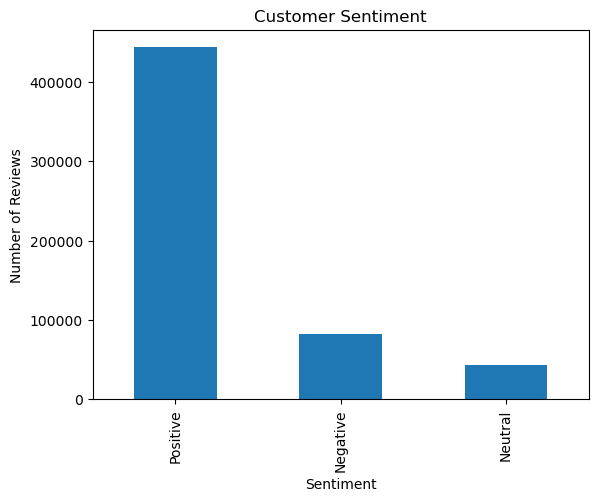

In [30]:
df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Customer Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [31]:
df.to_csv("../data/clean_reviews_with_sentiment.csv", index=False)

In [32]:
#AI Sentiment Analysis (NLP)

In [33]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [34]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [35]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Menakha\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [36]:
sia = SentimentIntensityAnalyzer()

In [37]:
print(df['Text'].iloc[0])

I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.


In [38]:
sia.polarity_scores(df['Text'].iloc[0])

{'neg': 0.0, 'neu': 0.695, 'pos': 0.305, 'compound': 0.9441}

In [40]:
df = df.sample(5000, random_state=42)

In [41]:
df['AI_Sentiment_Score'] = df['Text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

In [42]:
def ai_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['AI_Sentiment'] = df['AI_Sentiment_Score'].apply(ai_sentiment)

In [43]:
df[['Text', 'AI_Sentiment_Score', 'AI_Sentiment']].head(10)

,Text,AI_Sentiment_Score,AI_Sentiment
41434,These are actually very tasty. Pure potatoes ...,0.3182,Positive
209481,I realize that taste is a matter of personal p...,0.8346,Positive
247306,This is one of my Favorite cup of soup choices...,0.9848,Positive
80089,If you like the classic taste of a good margar...,0.9889,Positive
218580,I was willing to give this a chance even after...,0.9755,Positive
399096,can't keep enough of these treats in the house...,0.4588,Positive
16538,I LOVE this stuff. Imagine my joy to find it i...,0.9898,Positive
34007,Recommend it to all. Lovely natural sweet del...,0.9776,Positive
469948,A totally wonderful product! The flavor is in...,0.8677,Positive
497875,TOTALLY ORGASMIC. these chips are the best sp...,0.9350,Positive


In [44]:
df['AI_Sentiment'].value_counts()

AI_Sentiment
Positive    4392
Negative     503
Neutral      105
Name: count, dtype: int64

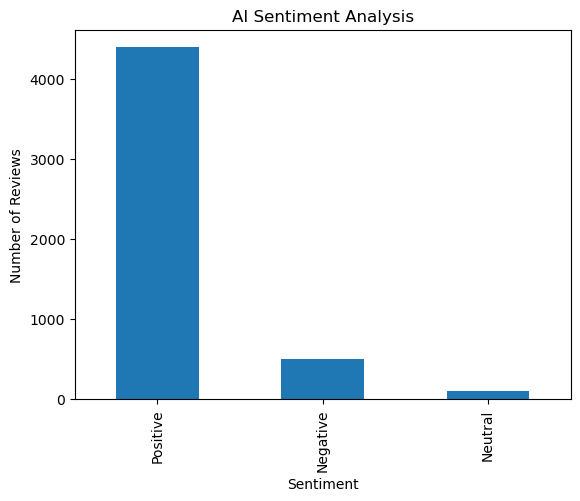

In [45]:
import matplotlib.pyplot as plt

df['AI_Sentiment'].value_counts().plot(kind='bar')

plt.title("AI Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [46]:
df.to_csv("../data/final_reviews.csv", index=False)

In [47]:
#Find the Top Positive and Negative Words

In [48]:
from collections import Counter
import re

In [49]:
positive_reviews = " ".join(df[df['AI_Sentiment'] == 'Positive']['Text'].astype(str))

In [50]:
positive_reviews = positive_reviews.lower()

positive_reviews = re.sub(r'[^a-zA-Z\s]', '', positive_reviews)

In [51]:
positive_words = Counter(positive_reviews.split())

In [52]:
positive_words.most_common(20)

[('the', 14580),
 ('i', 11991),
 ('and', 10502),
 ('a', 10178),
 ('to', 8233),
 ('it', 7219),
 ('of', 6540),
 ('is', 6010),
 ('this', 5403),
 ('for', 4573),
 ('in', 4444),
 ('my', 3807),
 ('that', 3489),
 ('with', 2865),
 ('have', 2847),
 ('but', 2822),
 ('you', 2742),
 ('are', 2594),
 ('not', 2496),
 ('was', 2463)]

In [53]:
negative_reviews = " ".join(df[df['AI_Sentiment'] == 'Negative']['Text'].astype(str))

negative_reviews = negative_reviews.lower()

negative_reviews = re.sub(r'[^a-zA-Z\s]', '', negative_reviews)

negative_words = Counter(negative_reviews.split())

negative_words.most_common(20)

[('the', 1684),
 ('i', 1419),
 ('and', 1028),
 ('a', 938),
 ('to', 933),
 ('it', 823),
 ('of', 737),
 ('this', 641),
 ('is', 567),
 ('in', 441),
 ('not', 441),
 ('was', 401),
 ('but', 401),
 ('for', 386),
 ('that', 376),
 ('my', 335),
 ('have', 303),
 ('with', 284),
 ('they', 250),
 ('on', 232)]

In [54]:
#Remove Stop Words

In [55]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Menakha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [56]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [57]:
positive_reviews = " ".join(
    df[df['AI_Sentiment'] == 'Positive']['Text'].astype(str)
)

positive_reviews = positive_reviews.lower()

positive_reviews = re.sub(r'[^a-zA-Z\s]', '', positive_reviews)

words = positive_reviews.split()

filtered_words = [word for word in words if word not in stop_words]

positive_words = Counter(filtered_words)

positive_words.most_common(20)

[('br', 2184),
 ('like', 1966),
 ('good', 1637),
 ('great', 1442),
 ('one', 1422),
 ('coffee', 1375),
 ('taste', 1323),
 ('food', 1150),
 ('flavor', 1110),
 ('love', 1095),
 ('product', 1062),
 ('tea', 1020),
 ('would', 1000),
 ('get', 887),
 ('really', 776),
 ('much', 740),
 ('also', 725),
 ('dont', 713),
 ('little', 701),
 ('use', 679)]

In [58]:
negative_reviews = " ".join(
    df[df['AI_Sentiment'] == 'Negative']['Text'].astype(str)
)

negative_reviews = negative_reviews.lower()

negative_reviews = re.sub(r'[^a-zA-Z\s]', '', negative_reviews)

words = negative_reviews.split()

filtered_words = [word for word in words if word not in stop_words]

negative_words = Counter(filtered_words)

negative_words.most_common(20)

[('br', 198),
 ('like', 188),
 ('product', 167),
 ('one', 153),
 ('taste', 139),
 ('would', 133),
 ('food', 120),
 ('tea', 108),
 ('good', 108),
 ('coffee', 108),
 ('dont', 96),
 ('flavor', 94),
 ('really', 86),
 ('get', 78),
 ('bad', 78),
 ('time', 76),
 ('buy', 75),
 ('im', 74),
 ('eat', 73),
 ('box', 72)]

In [59]:
df.to_csv("../data/final_reviews.csv", index=False)

In [60]:
import pandas as pd

df = pd.read_csv("../data/Reviews.csv")

In [61]:
df_5000 = df.sample(n=5000, random_state=42)

In [62]:
df_5000.to_csv("../data/Reviews_5000.csv", index=False)

In [63]:
import os
os.getcwd()

'C:\\Users\\Menakha\\Downloads\\Excel project\\AI_Customer_Feedback_Analyzer\\notebooks'

In [64]:
df_5000 = df.sample(n=5000, random_state=42)

In [65]:
df_5000.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
165256,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
231465,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...
427827,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...
433954,433955,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,0,1,2,1335312000,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin..."
70260,70261,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,0,2,5,1334707200,Great Taste . . .,and I want to congratulate the graphic artist ...


In [66]:
df_5000.to_csv("../data/Reviews_5000.csv", index=False)

In [67]:
import os
os.listdir("../data")

['clean_reviews.csv',
 'clean_reviews_with_sentiment.csv',
 'database.sqlite',
 'final_reviews.csv',
 'Reviews.csv',
 'Reviews_5000.csv']

In [68]:
import os

print(os.path.abspath("../data/Reviews_5000.csv"))

C:\Users\Menakha\Downloads\Excel project\AI_Customer_Feedback_Analyzer\data\Reviews_5000.csv


In [69]:
import pandas as pd

positive_df = pd.DataFrame(
    positive_words.most_common(10),
    columns=["Word", "Count"]
)

positive_df

,Word,Count
0,br,2184
1,like,1966
2,good,1637
3,great,1442
4,one,1422
5,coffee,1375
6,taste,1323
7,food,1150
8,flavor,1110
9,love,1095


In [70]:
positive_df.to_csv("../data/top_positive_words.csv", index=False)

In [71]:
negative_df = pd.DataFrame(
    negative_words.most_common(10),
    columns=["Word", "Count"]
)

negative_df

,Word,Count
0,br,198
1,like,188
2,product,167
3,one,153
4,taste,139
5,would,133
6,food,120
7,tea,108
8,good,108
9,coffee,108


In [72]:
negative_df.to_csv("../data/top_negative_words.csv", index=False)